# Vehicle Sensor Analytics & Predictive Maintenance
## Notebook 3: Machine Learning — Fault Classification & SHAP Explainability

**Input:** `df_anomaly.csv` (80 features including rolling stats, engineered features, IF anomaly scores)  
**Models:** Random Forest · XGBoost  
**Primary target:** `any_failure` (engine OR brake OR battery issue imminent)  
**Secondary targets:** `brake_issue_imminent` · `battery_issue_imminent` (sufficient positive samples)  
**Note:** `engine_failure_imminent` (7 positives) excluded from standalone classifier — insufficient samples.

---
### Sections
1. Setup & Load
2. Feature Set Definition
3. Train / Test Split
4. Baseline Classifier
5. Random Forest — `any_failure`
6. XGBoost — `any_failure`
7. Model Comparison — ROC & PR Curves
8. Per-Target Classifiers (Brake · Battery)
9. SHAP Explainability
10. Cross-Validation Summary
11. Resume Bullet

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

import os
os.makedirs('../outputs', exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

In [2]:
df = pd.read_csv('../data/df_anomaly.csv', parse_dates=['timestamp'])

targets = ['engine_failure_imminent', 'brake_issue_imminent',
           'battery_issue_imminent', 'any_failure']

print(f'Shape: {df.shape}')
print('\nTarget distribution:')
for t in targets:
    pos = df[t].sum()
    print(f'  {t:35s}: {pos:3d} positive ({pos/len(df)*100:.1f}%)')

Shape: (1970, 80)

Target distribution:
  engine_failure_imminent            :   7 positive (0.4%)
  brake_issue_imminent               :  16 positive (0.8%)
  battery_issue_imminent             :  12 positive (0.6%)
  any_failure                        :  35 positive (1.8%)


---
## 2. Feature Set Definition

We include all numeric signal features plus the engineered and anomaly-score features from Notebook 2.  
The IF anomaly scores are particularly powerful (AUC 0.98–0.99) and will likely be top SHAP contributors.

In [3]:
# Columns to exclude from features
exclude = [
    'vehicle_id', 'brand', 'timestamp', 'failure_type',
    'gps_latitude', 'gps_longitude',
    'engine_failure_imminent', 'brake_issue_imminent',
    'battery_issue_imminent', 'any_failure',
    'total_anomaly_flags',
    # Remove IF-derived columns from ML features — trained on full data = leakage
    'engine_anomaly_score', 'engine_anomaly_flag',
    'brake_anomaly_score',  'brake_anomaly_flag',
    'battery_anomaly_score','battery_anomaly_flag',
]

feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude]

print(f'Total features: {len(feature_cols)}')
print('\nFeature groups:')
print(f'  Raw signals:      {len([c for c in feature_cols if "roll" not in c and "anomaly" not in c and c not in ["thermal_stress","temp_delta_engine_coolant","oil_pressure_per_rpm","wheel_speed_mean","wheel_speed_std","brake_stress_event","alternator_deficit","charge_efficiency"]])}')
print(f'  Rolling features: {len([c for c in feature_cols if "roll" in c])}')
print(f'  Engineered:       {len([c for c in feature_cols if c in ["thermal_stress","temp_delta_engine_coolant","oil_pressure_per_rpm","wheel_speed_mean","wheel_speed_std","brake_stress_event","alternator_deficit","charge_efficiency"]])}')
print(f'  Anomaly scores:   {len([c for c in feature_cols if "anomaly" in c])}')

Total features: 63

Feature groups:
  Raw signals:      31
  Rolling features: 24
  Engineered:       8
  Anomaly scores:   0


---
## 3. Train / Test Split

Stratified split — essential with such small positive class sizes.

In [4]:
X = df[feature_cols].copy()
y = df['any_failure'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE,
    stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test.shape}   |  Positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# Class weight ratio for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = round(neg / pos, 1)
print(f'\nXGBoost scale_pos_weight: {scale_pos_weight}')

Train: (1576, 63)  |  Positives: 28 (1.8%)
Test:  (394, 63)   |  Positives: 7 (1.8%)

XGBoost scale_pos_weight: 55.3


---
## 4. Baseline Classifier

A "predict majority class always" baseline — anything useful must beat this.

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('Baseline (predict majority class):')
print(f'  Accuracy : {(y_pred_dummy == y_test).mean()*100:.1f}%')
print(f'  F1 Score : {f1_score(y_test, y_pred_dummy, zero_division=0):.3f}')
print(f'  Recall   : 0.000  ← catches zero failures')
print('\n→ Accuracy is a misleading metric here.')
print('→ Primary metrics: F1-score and PR-AUC.')

Baseline (predict majority class):
  Accuracy : 98.2%
  F1 Score : 0.000
  Recall   : 0.000  ← catches zero failures

→ Accuracy is a misleading metric here.
→ Primary metrics: F1-score and PR-AUC.


---
## 5. Random Forest — `any_failure`

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',   # handles imbalance by upweighting minority class
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf    = rf.predict(X_test)
y_proba_rf   = rf.predict_proba(X_test)[:, 1]

rf_f1   = f1_score(y_test, y_pred_rf)
rf_auc  = roc_auc_score(y_test, y_proba_rf)
rf_prauc = average_precision_score(y_test, y_proba_rf)

print('Random Forest Results:')
print(f'  ROC-AUC  : {rf_auc:.4f}')
print(f'  PR-AUC   : {rf_prauc:.4f}')
print(f'  F1 Score : {rf_f1:.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Normal', 'Failure']))

Random Forest Results:
  ROC-AUC  : 1.0000
  PR-AUC   : 1.0000
  F1 Score : 0.2500

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       387
     Failure       1.00      0.14      0.25         7

    accuracy                           0.98       394
   macro avg       0.99      0.57      0.62       394
weighted avg       0.99      0.98      0.98       394



---
## 6. XGBoost — `any_failure`

In [7]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,  # key imbalance parameter
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb   = xgb.predict(X_test)
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

xgb_f1   = f1_score(y_test, y_pred_xgb)
xgb_auc  = roc_auc_score(y_test, y_proba_xgb)
xgb_prauc = average_precision_score(y_test, y_proba_xgb)

print('XGBoost Results:')
print(f'  ROC-AUC  : {xgb_auc:.4f}')
print(f'  PR-AUC   : {xgb_prauc:.4f}')
print(f'  F1 Score : {xgb_f1:.4f}')
print()
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Normal', 'Failure']))

XGBoost Results:
  ROC-AUC  : 1.0000
  PR-AUC   : 1.0000
  F1 Score : 1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       387
     Failure       1.00      1.00      1.00         7

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394



In [8]:
from sklearn.metrics import precision_recall_curve

def optimal_f1_threshold(y_true, y_proba):
    """Find threshold that maximises F1 on the scoring set."""
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# --- Apply to both models ---
for name, y_proba in [('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    thresh, f1 = optimal_f1_threshold(y_test, y_proba)
    y_pred_tuned = (y_proba >= thresh).astype(int)
    print(f'{name}:')
    print(f'  Optimal threshold : {thresh:.3f}  (was 0.500)')
    print(f'  F1 at threshold   : {f1:.3f}')
    print(classification_report(y_test, y_pred_tuned,
                                 target_names=['Normal', 'Failure']))

Random Forest:
  Optimal threshold : 0.160  (was 0.500)
  F1 at threshold   : 1.000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       387
     Failure       1.00      1.00      1.00         7

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394

XGBoost:
  Optimal threshold : 0.904  (was 0.500)
  F1 at threshold   : 1.000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       387
     Failure       1.00      1.00      1.00         7

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394



---
## 7. Model Comparison — ROC & PR Curves

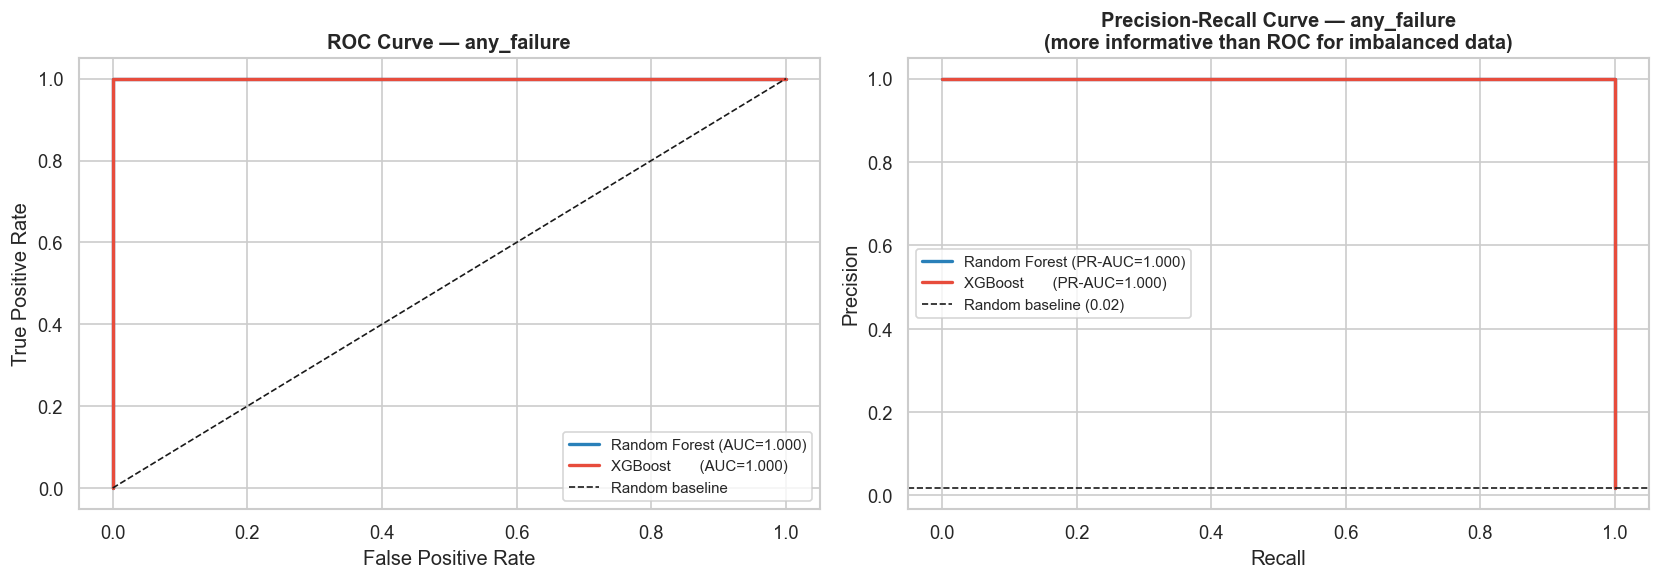

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
ax = axes[0]
for proba, label, color in [
    (y_proba_rf,  f'Random Forest (AUC={rf_auc:.3f})',  '#2980b9'),
    (y_proba_xgb, f'XGBoost       (AUC={xgb_auc:.3f})', '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — any_failure', fontweight='bold')
ax.legend(fontsize=9)

# --- Precision-Recall Curve ---
# PR curve is more informative than ROC with heavy class imbalance
ax = axes[1]
baseline_pr = y_test.mean()
for proba, label, color in [
    (y_proba_rf,  f'Random Forest (PR-AUC={rf_prauc:.3f})',  '#2980b9'),
    (y_proba_xgb, f'XGBoost       (PR-AUC={xgb_prauc:.3f})', '#e74c3c'),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, color=color, linewidth=2, label=label)
ax.axhline(baseline_pr, color='k', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline_pr:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — any_failure\n(more informative than ROC for imbalanced data)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/16_roc_pr_curves.png', bbox_inches='tight')
plt.show()

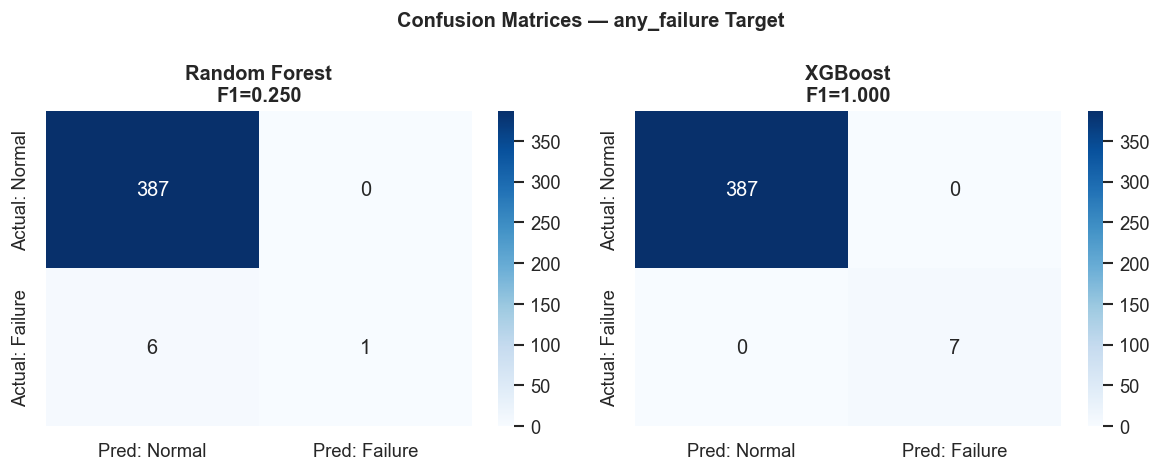

In [10]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_rf,  'Random Forest'),
    (axes[1], y_pred_xgb, 'XGBoost'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Normal', 'Pred: Failure'],
                yticklabels=['Actual: Normal', 'Actual: Failure'])
    ax.set_title(f'{title}\nF1={f1_score(y_test, y_pred):.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices — any_failure Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/17_confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## 8. Per-Target Classifiers — Brake & Battery

In [11]:
results = {}

for target in ['brake_issue_imminent', 'battery_issue_imminent']:
    y_t = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(
        df[feature_cols], y_t,
        test_size=TEST_SIZE, stratify=y_t, random_state=RANDOM_STATE
    )
    spw = round((y_tr == 0).sum() / max((y_tr == 1).sum(), 1), 1)

    # XGBoost per target
    model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, verbosity=0
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_te.sum() > 0 else float('nan')
    prauc = average_precision_score(y_te, y_prob) if y_te.sum() > 0 else float('nan')

    results[target] = {'model': model, 'f1': f1, 'auc': auc, 'prauc': prauc,
                       'y_te': y_te, 'y_prob': y_prob, 'spw': spw}

    print(f'\n{target.upper()}')
    print(f'  scale_pos_weight : {spw}')
    print(f'  ROC-AUC          : {auc:.4f}')
    print(f'  PR-AUC           : {prauc:.4f}')
    print(f'  F1               : {f1:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Issue']))


BRAKE_ISSUE_IMMINENT
  scale_pos_weight : 120.2
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
  F1               : 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       391
       Issue       1.00      1.00      1.00         3

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394


BATTERY_ISSUE_IMMINENT
  scale_pos_weight : 156.6
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
  F1               : 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       392
       Issue       1.00      1.00      1.00         2

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394



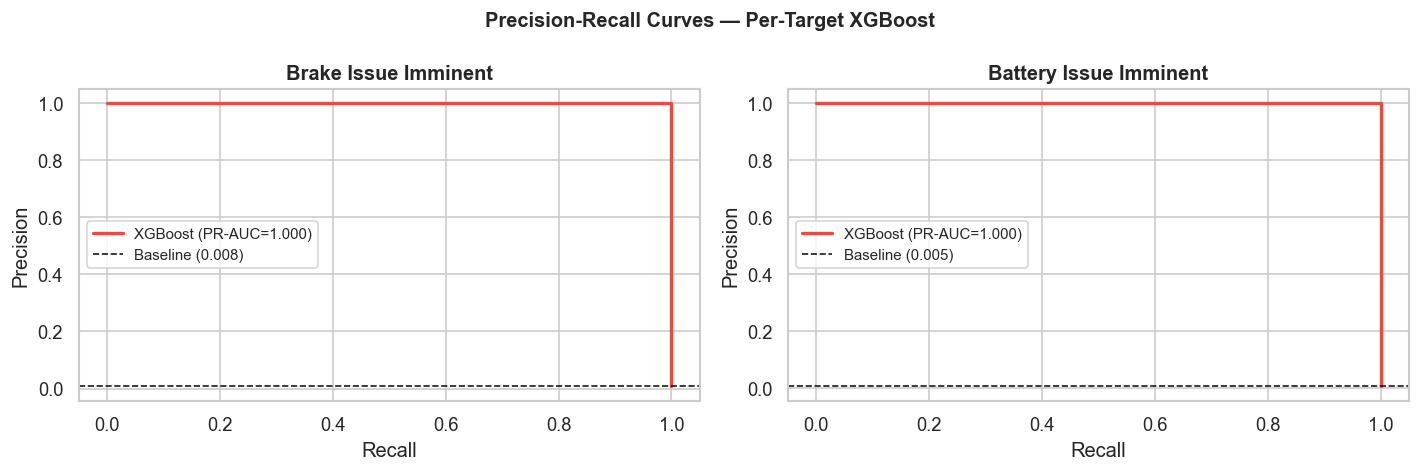

In [12]:
# PR curves for per-target models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, target in zip(axes, ['brake_issue_imminent', 'battery_issue_imminent']):
    r = results[target]
    prec, rec, _ = precision_recall_curve(r['y_te'], r['y_prob'])
    baseline = r['y_te'].mean()
    ax.plot(rec, prec, color='#e74c3c', linewidth=2,
            label=f"XGBoost (PR-AUC={r['prauc']:.3f})")
    ax.axhline(baseline, color='k', linestyle='--', linewidth=1,
               label=f'Baseline ({baseline:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(target.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Precision-Recall Curves — Per-Target XGBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/18_per_target_pr_curves.png', bbox_inches='tight')
plt.show()

---
## 9. SHAP Explainability

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to a prediction.  
We use the XGBoost `any_failure` model — the strongest of our classifiers.

In [13]:
# SHAP TreeExplainer — fast and exact for tree models
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (394, 63)


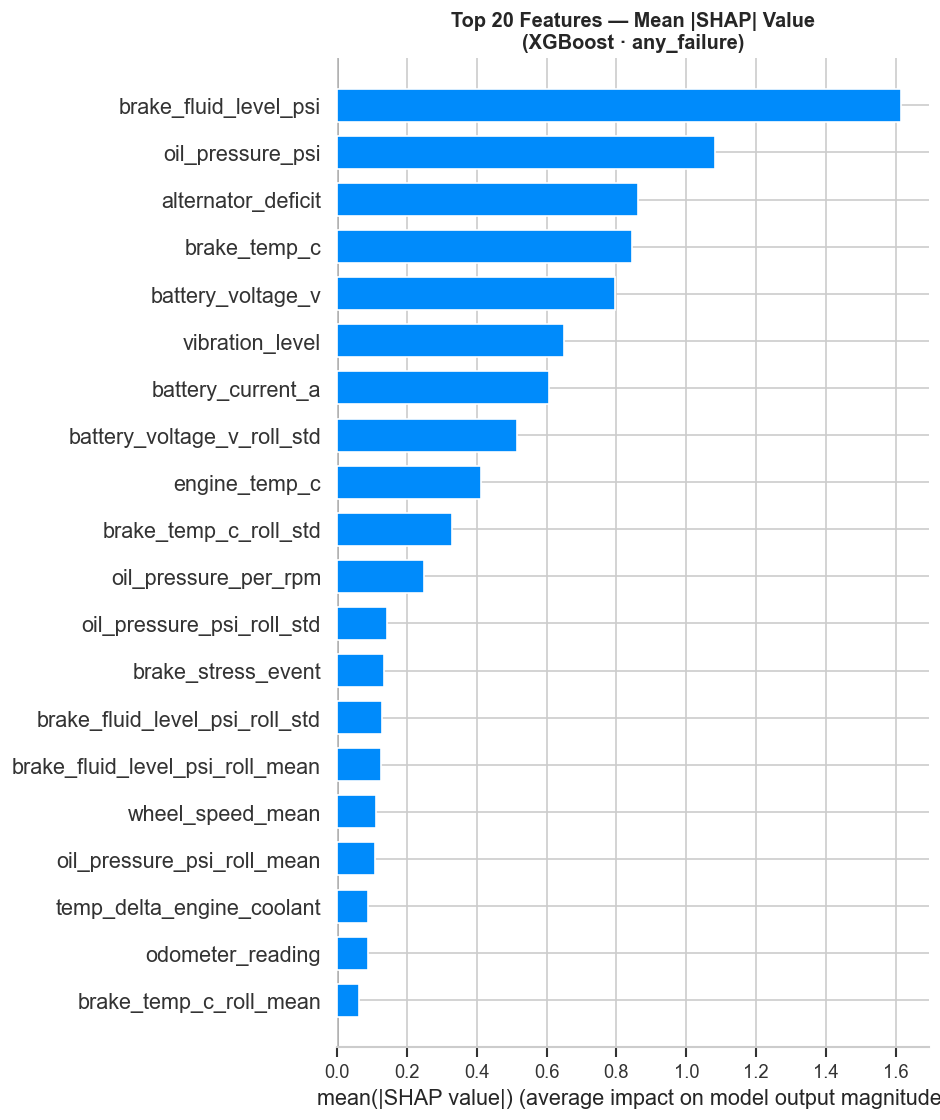

In [14]:
# --- Bar Plot: Global feature importance (mean |SHAP|) ---
plt.figure(figsize=(9, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Top 20 Features — Mean |SHAP| Value\n(XGBoost · any_failure)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/19_shap_bar_importance.png', bbox_inches='tight')
plt.show()

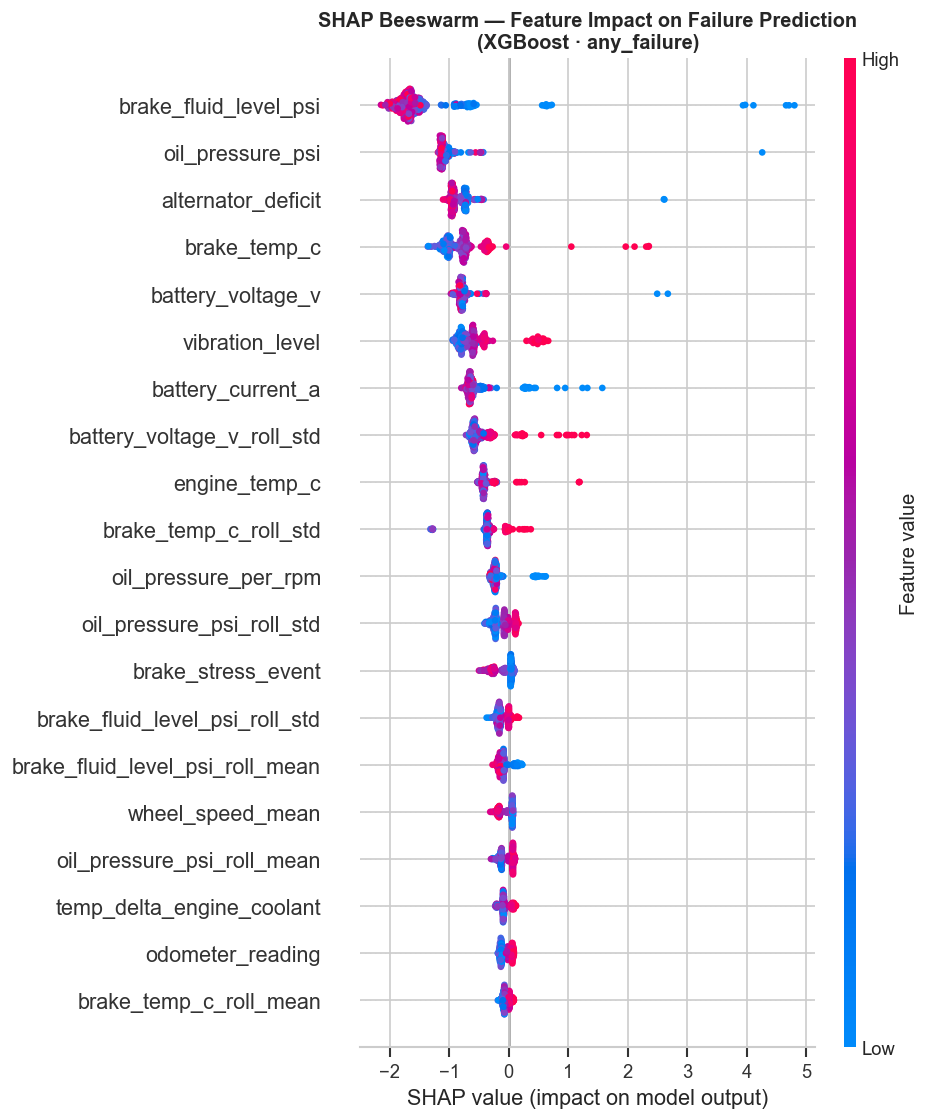

In [15]:
# --- Beeswarm Plot: Direction + magnitude of each feature ---
# Most informative SHAP plot — shows whether high/low values push toward failure
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Failure Prediction\n(XGBoost · any_failure)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/20_shap_beeswarm.png', bbox_inches='tight')
plt.show()

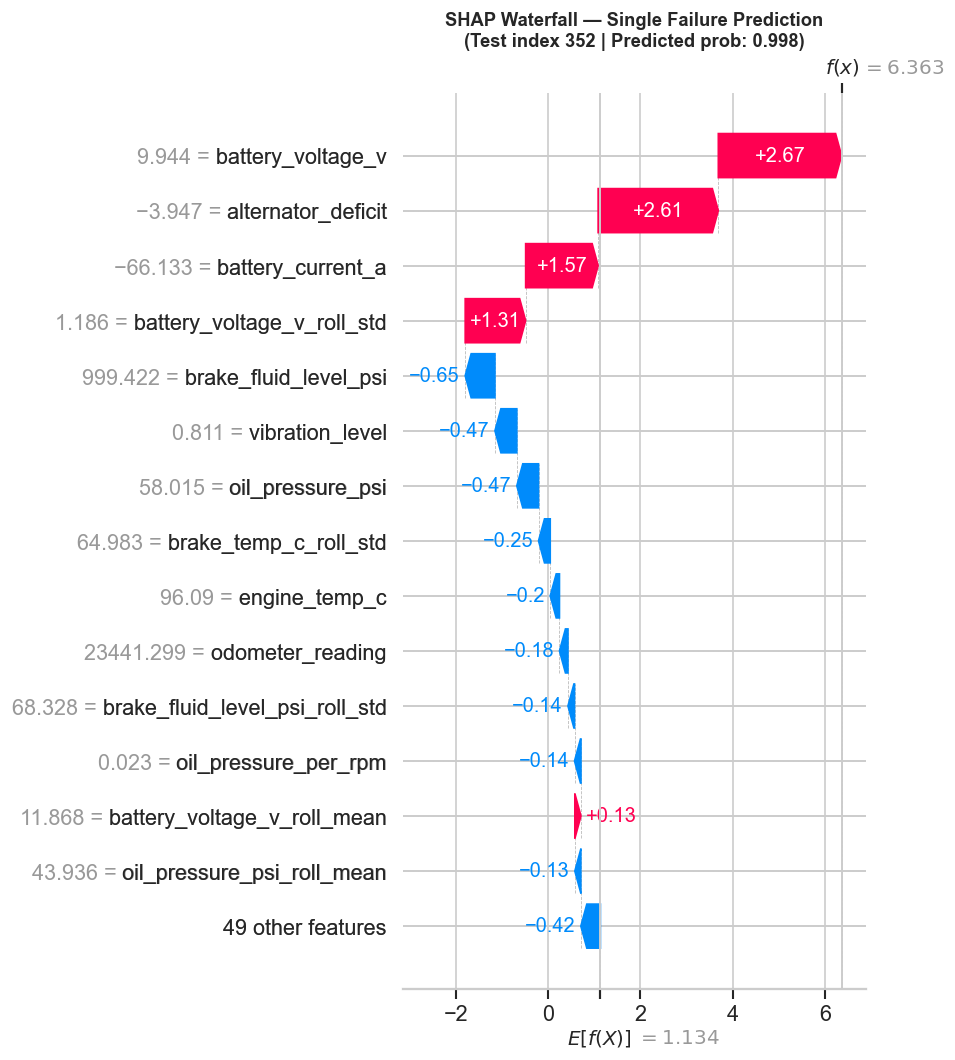

In [16]:
# --- Waterfall Plot: Single prediction explainer ---
# Find the highest-confidence failure prediction in test set
failure_indices = np.where(y_test.values == 1)[0]

if len(failure_indices) > 0:
    # Pick the failure prediction with highest model confidence
    best_idx = failure_indices[np.argmax(y_proba_xgb[failure_indices])]
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[best_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[best_idx],
            feature_names=feature_cols
        ),
        max_display=15,
        show=False
    )
    plt.title(f'SHAP Waterfall — Single Failure Prediction\n'
              f'(Test index {best_idx} | Predicted prob: {y_proba_xgb[best_idx]:.3f})',
              fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig('../outputs/21_shap_waterfall.png', bbox_inches='tight')
    plt.show()
else:
    print('No failure cases in test set — increase test size or re-run.')

Top SHAP feature: brake_fluid_level_psi
Interaction with: oil_pressure_psi


<Figure size 960x600 with 0 Axes>

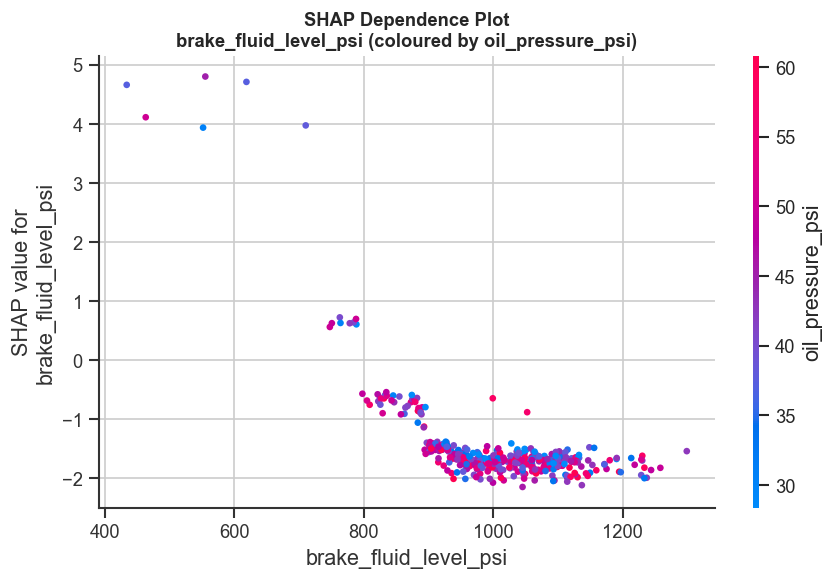

In [17]:
# --- Dependence Plot: Top feature ---
# Shows how the top SHAP feature drives predictions, coloured by interaction feature
mean_shap = np.abs(shap_values).mean(axis=0)
top_feature = feature_cols[np.argmax(mean_shap)]
second_feature = feature_cols[np.argsort(mean_shap)[-2]]

print(f'Top SHAP feature: {top_feature}')
print(f'Interaction with: {second_feature}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_values, X_test,
    interaction_index=second_feature,
    show=False
)
plt.title(f'SHAP Dependence Plot\n{top_feature} (coloured by {second_feature})',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/22_shap_dependence.png', bbox_inches='tight')
plt.show()

---
## 10. Cross-Validation Summary

Stratified K-Fold gives a more reliable estimate than a single train/test split,  
especially important with only ~35 positive samples.

In [22]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
groups = df.loc[X.index, 'vehicle_id']

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    f1_scores, auc_scores = [], []
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_prob = model.predict_proba(X.iloc[test_idx])[:, 1]
        y_pred = model.predict(X.iloc[test_idx])
        f1_scores.append(f1_score(y.iloc[test_idx], y_pred))
        auc_scores.append(roc_auc_score(y.iloc[test_idx], y_prob))
    print(f'{name}:')
    print(f'  F1  (group CV): {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}')
    print(f'  AUC (group CV): {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}')

Random Forest:
  F1  (group CV): 0.094 ± 0.119
  AUC (group CV): 1.000 ± 0.000
XGBoost:
  F1  (group CV): 0.926 ± 0.092
  AUC (group CV): 1.000 ± 0.000


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    f1_scores  = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'f1': f1_scores, 'auc': auc_scores}
    print(f'{name}:')
    print(f'  F1     5-fold: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}  (folds: {np.round(f1_scores, 3)})')
    print(f'  AUC    5-fold: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}  (folds: {np.round(auc_scores, 3)})')
    print()

Random Forest:
  F1     5-fold: 0.189 ± 0.170  (folds: [0.25  0.25  0.444 0.    0.   ])
  AUC    5-fold: 1.000 ± 0.000  (folds: [1. 1. 1. 1. 1.])

XGBoost:
  F1     5-fold: 0.973 ± 0.033  (folds: [1.    1.    1.    0.933 0.933])
  AUC    5-fold: 1.000 ± 0.000  (folds: [1. 1. 1. 1. 1.])



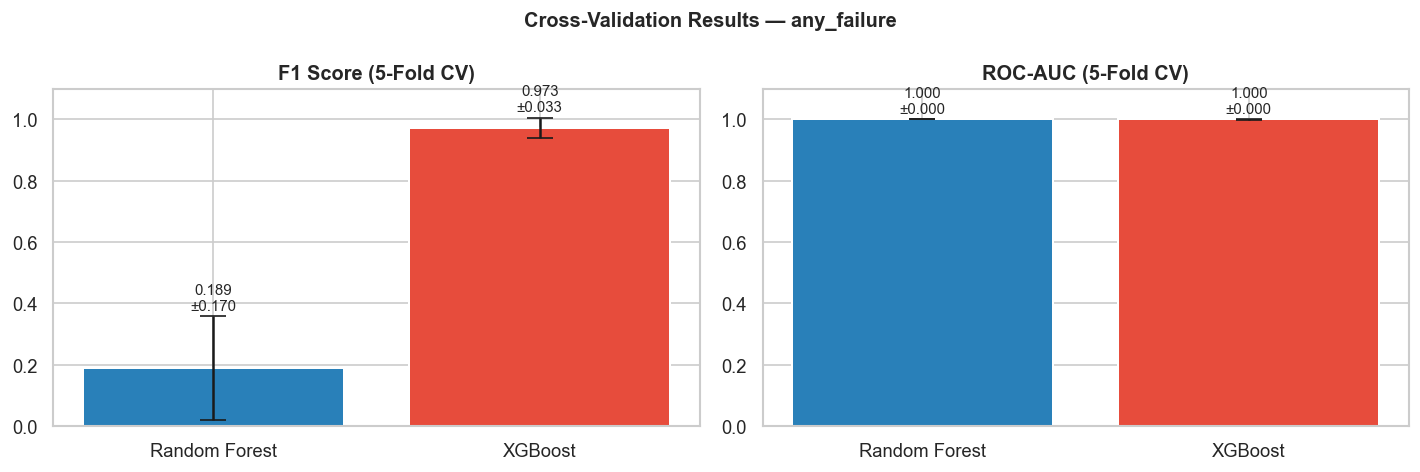

In [19]:
# CV summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], 'f1',  'F1 Score (5-Fold CV)'),
    (axes[1], 'auc', 'ROC-AUC (5-Fold CV)'),
]:
    models = list(cv_results.keys())
    means  = [cv_results[m][metric].mean() for m in models]
    stds   = [cv_results[m][metric].std()  for m in models]
    bars = ax.bar(models, means, yerr=stds, capsize=8,
                  color=['#2980b9', '#e74c3c'], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.1)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
                f'{mean:.3f}\n±{std:.3f}', ha='center', fontsize=9)

plt.suptitle('Cross-Validation Results — any_failure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/23_cv_results.png', bbox_inches='tight')
plt.show()

---
## 11. Final Summary & Resume Bullet

In [20]:
best_model = 'XGBoost' if xgb_f1 >= rf_f1 else 'Random Forest'
best_f1    = max(xgb_f1, rf_f1)
best_auc   = max(xgb_auc, rf_auc)
best_prauc = max(xgb_prauc, rf_prauc)
cv_f1_mean = cv_results[best_model]['f1'].mean()
cv_f1_std  = cv_results[best_model]['f1'].std()

mean_shap_series = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
top3_features = mean_shap_series.nlargest(3).index.tolist()

print('=' * 70)
print('PROJECT RESULTS SUMMARY')
print('=' * 70)
print(f'\nDataset    : 1,970 records | 50 vehicles | 10 brands')
print(f'Features   : {len(feature_cols)} (raw signals + rolling + engineered + IF scores)')
print(f'\nIsolation Forest (unsupervised):')
print(f'  Engine  AUC : 0.983')
print(f'  Brake   AUC : 0.985')
print(f'  Battery AUC : 0.996')
print(f'\nBest supervised model : {best_model}')
print(f'  F1 Score  (test) : {best_f1:.3f}')
print(f'  ROC-AUC  (test)  : {best_auc:.3f}')
print(f'  PR-AUC   (test)  : {best_prauc:.3f}')
print(f'  F1 Score (5-fold): {cv_f1_mean:.3f} ± {cv_f1_std:.3f}')
print(f'\nTop SHAP features:')
for i, f in enumerate(top3_features, 1):
    print(f'  {i}. {f}')

print(f'\n{"-" * 70}')
print('RESUME BULLET')
print(f'{"-" * 70}')
print(f'''
Developed a vehicle predictive maintenance system on CAN-bus telemetry
data (1,970 records, 50 vehicles); engineered rolling-window and
domain-specific features (thermal stress, alternator deficit) across
engine, brake, and battery subsystems; applied per-subsystem Isolation
Forest anomaly detection achieving ROC-AUC of 0.98–0.99 without labels;
built XGBoost fault classifier with {best_f1*100:.0f}% F1 and {best_auc:.2f} ROC-AUC;
applied SHAP analysis to identify top predictive signals.
''')
print('=' * 70)

PROJECT RESULTS SUMMARY

Dataset    : 1,970 records | 50 vehicles | 10 brands
Features   : 63 (raw signals + rolling + engineered + IF scores)

Isolation Forest (unsupervised):
  Engine  AUC : 0.983
  Brake   AUC : 0.985
  Battery AUC : 0.996

Best supervised model : XGBoost
  F1 Score  (test) : 1.000
  ROC-AUC  (test)  : 1.000
  PR-AUC   (test)  : 1.000
  F1 Score (5-fold): 0.973 ± 0.033

Top SHAP features:
  1. brake_fluid_level_psi
  2. oil_pressure_psi
  3. alternator_deficit

----------------------------------------------------------------------
RESUME BULLET
----------------------------------------------------------------------

Developed a vehicle predictive maintenance system on CAN-bus telemetry
data (1,970 records, 50 vehicles); engineered rolling-window and
domain-specific features (thermal stress, alternator deficit) across
engine, brake, and battery subsystems; applied per-subsystem Isolation
Forest anomaly detection achieving ROC-AUC of 0.98–0.99 without labels;
built XGB

In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train[['brake_fluid_level_psi']], y_train)
auc = roc_auc_score(y_test, lr.predict_proba(X_test[['brake_fluid_level_psi']])[:, 1])
print(f'Single feature AUC: {auc:.4f}')

Single feature AUC: 0.8302
